# NB08: Cross-Validation Design

Design and evaluate temporal blocking CV strategies for the target domain.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import expit
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '/Users/dlau/repos/fish-welfare/data/'
OUT_DIR = '/Users/dlau/repos/fish-welfare/ModelSelection/'
np.random.seed(42)
print("Imports OK")

Imports OK


In [2]:
try:
    tgt = pd.read_csv(DATA_DIR + 'nb04_target_features.csv', parse_dates=['date'])
    print("Loaded nb04_target_features.csv:", tgt.shape)
except:
    tgt = pd.read_csv(DATA_DIR + 'nb01_target_daily_features.csv', parse_dates=['date'])
    wq = pd.read_csv(DATA_DIR + 'water_quality.csv')
    target_wq = wq[(wq['region']=='Eluru')&(wq['Type']=='Morning')&(wq['Is follow up']=='No')].copy()
    target_wq['date'] = pd.to_datetime(target_wq['Date of data collection'], format='%m/%d/%Y')
    target_wq['DO'] = pd.to_numeric(target_wq['DO (mg/L)'], errors='coerce')
    daily_out = target_wq.dropna(subset=['DO']).groupby('date').agg(
        n_total=('DO','count'), n_low=('DO',lambda x:(x<3).sum())
    ).reset_index()
    daily_out['frac_low'] = daily_out['n_low']/daily_out['n_total']
    tgt = tgt.merge(daily_out, on='date', how='inner')
    tgt['log_n_ponds'] = np.log1p(tgt['n_total'])

import json
try:
    with open(DATA_DIR + 'nb04_selected_features.json') as f:
        feat_info = json.load(f)
    features = [f for f in feat_info['tgt_available'] if f in tgt.columns]
except:
    features = [c for c in tgt.columns if c not in ['date','n_total','n_low','frac_low','bad_day',
                'log_n_ponds','month','season','mean_do','n_ponds']]

# Sort chronologically
tgt = tgt.sort_values('date').reset_index(drop=True)
print("Target shape:", tgt.shape)
print("Features:", features)

Loaded nb04_target_features.csv: (746, 11)
Target shape: (746, 11)
Features: ['month_sin', 'night_precip_sum', 'precip_2d_sum', 'doy_cos', 'night_wind_min']


## 2. Train/Test Split (80/20 Chronological)

In [3]:
n = len(tgt)
split_idx = int(n * 0.8)
train = tgt.iloc[:split_idx].copy()
test = tgt.iloc[split_idx:].copy()

print(f"Train: {len(train)} rows ({train['date'].min().date()} to {train['date'].max().date()})")
print(f"Test:  {len(test)} rows ({test['date'].min().date()} to {test['date'].max().date()})")
print(f"\nTrain frac_low: mean={train['frac_low'].mean():.3f}, std={train['frac_low'].std():.3f}")
print(f"Test frac_low:  mean={test['frac_low'].mean():.3f}, std={test['frac_low'].std():.3f}")

Train: 596 rows (2021-07-12 to 2025-06-05)
Test:  150 rows (2025-06-06 to 2026-01-27)

Train frac_low: mean=0.183, std=0.315
Test frac_low:  mean=0.073, std=0.170


## 3-4. Temporal Blocking CV: 30, 60, 90-day folds

In [4]:
def brier_score(y_true, y_pred):
    """Brier score for probability predictions."""
    return np.mean((y_pred - y_true)**2)

def log_loss_score(y_true, y_pred, eps=1e-7):
    """Binary log-loss."""
    y_pred = np.clip(y_pred, eps, 1-eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def fit_predict_glm(X_train, y_train, n_train, k_train, X_val):
    """Fit Binomial GLM and predict."""
    try:
        Xc = sm.add_constant(X_train)
        Xv = sm.add_constant(X_val)
        model = sm.GLM(
            np.column_stack([k_train, n_train - k_train]),
            Xc,
            family=sm.families.Binomial()
        ).fit(disp=False)
        return model.predict(Xv)
    except:
        return np.full(len(X_val), y_train.mean())

def temporal_block_cv(df, features, fold_days):
    """Temporal blocking CV with given fold size in days."""
    df = df.sort_values('date').reset_index(drop=True)
    avail_feats = [f for f in features if f in df.columns]
    if not avail_feats:
        return []
    
    df_clean = df[['date','n_total','n_low','frac_low'] + avail_feats].dropna()
    if len(df_clean) < fold_days * 2:
        return []
    
    n = len(df_clean)
    results = []
    i = 0
    while i + fold_days < n:
        train_df = df_clean.iloc[:i + fold_days]
        val_df = df_clean.iloc[i + fold_days: i + 2 * fold_days]
        
        if len(train_df) < 10 or len(val_df) < 3:
            i += fold_days
            continue
        
        X_tr = (train_df[avail_feats] - train_df[avail_feats].mean()) / (train_df[avail_feats].std() + 1e-10)
        X_va = (val_df[avail_feats] - train_df[avail_feats].mean()) / (train_df[avail_feats].std() + 1e-10)
        
        preds = fit_predict_glm(
            X_tr.values, train_df['frac_low'].values,
            train_df['n_total'].values, train_df['n_low'].values,
            X_va.values
        )
        
        y_true = val_df['frac_low'].values
        bs = brier_score(y_true, preds)
        ll = log_loss_score(y_true, preds)
        results.append({'fold_start': i, 'n_train': len(train_df), 'n_val': len(val_df), 
                        'brier': bs, 'log_loss': ll})
        i += fold_days
    
    return results

print("Running temporal block CV...")
cv_results = {}
for fd in [30, 60, 90]:
    res = temporal_block_cv(train, features, fd)
    cv_results[fd] = res
    if res:
        bs_mean = np.mean([r['brier'] for r in res])
        ll_mean = np.mean([r['log_loss'] for r in res])
        print(f"  {fd}-day folds: {len(res)} folds, Brier={bs_mean:.4f}, LogLoss={ll_mean:.4f}")
    else:
        print(f"  {fd}-day folds: insufficient data")

Running temporal block CV...
  30-day folds: 19 folds, Brier=0.1001, LogLoss=0.4784
  60-day folds: 9 folds, Brier=0.0997, LogLoss=0.4785
  90-day folds: 6 folds, Brier=0.1034, LogLoss=0.4859


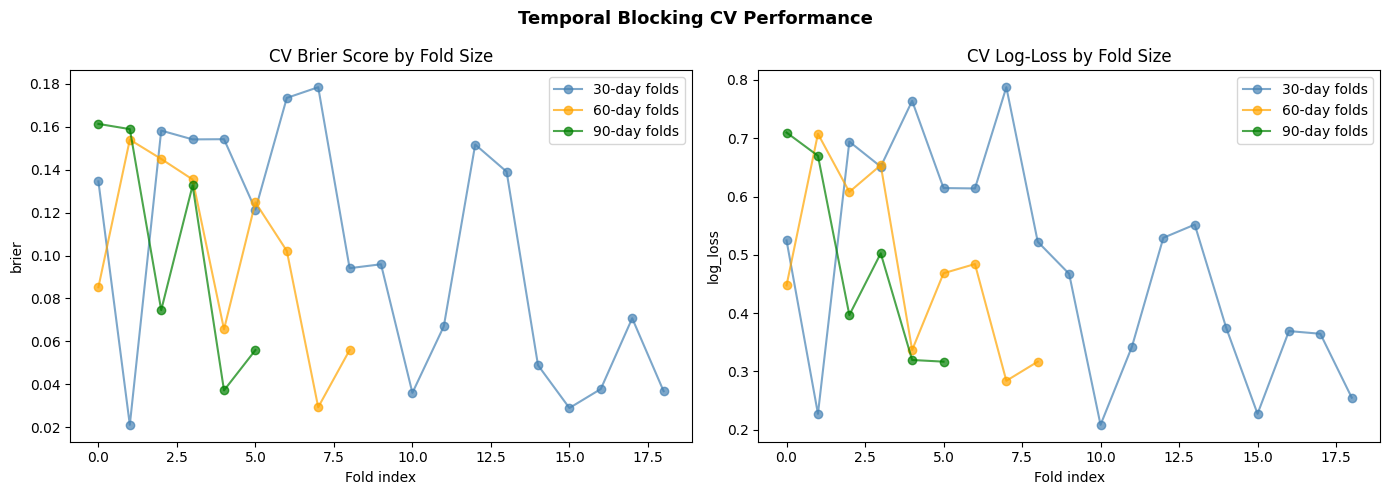

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for metric_idx, (metric, title) in enumerate([('brier', 'Brier Score'), ('log_loss', 'Log-Loss')]):
    ax = axes[metric_idx]
    for fd, color in [(30, 'steelblue'), (60, 'orange'), (90, 'green')]:
        res = cv_results.get(fd, [])
        if res:
            vals = [r[metric] for r in res]
            ax.plot(range(len(vals)), vals, 'o-', color=color, alpha=0.7, label=f'{fd}-day folds')
    ax.set_xlabel('Fold index')
    ax.set_ylabel(metric)
    ax.set_title(f'CV {title} by Fold Size')
    ax.legend()

plt.suptitle('Temporal Blocking CV Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + 'nb08_cv_performance.png', dpi=80, bbox_inches='tight')
plt.show()

## 6. Seasonal Performance Analysis

Seasonal CV performance:
      season  n  brier  log_loss
     monsoon 78 0.0783    0.3970
post_monsoon 37 0.0464    0.3525
      winter 35 0.0212    0.2393


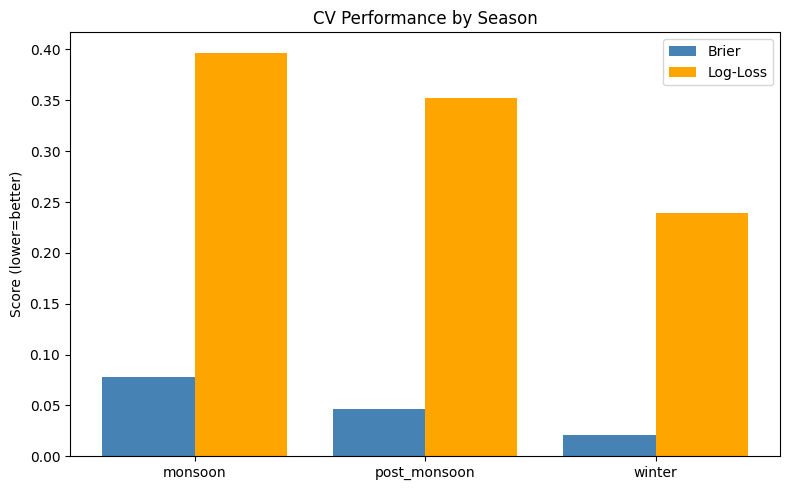

In [6]:
def assign_season(m):
    if m in [6,7,8,9]: return 'monsoon'
    if m in [10,11]: return 'post_monsoon'
    if m in [12,1,2]: return 'winter'
    return 'pre_monsoon'

avail_feats = [f for f in features if f in tgt.columns]
if avail_feats:
    tgt_clean = tgt[['date','n_total','n_low','frac_low'] + avail_feats].dropna().copy()
    tgt_clean['month'] = tgt_clean['date'].dt.month
    tgt_clean['season'] = tgt_clean['month'].apply(assign_season)
    
    train_clean = tgt_clean.iloc[:int(len(tgt_clean)*0.8)]
    test_clean = tgt_clean.iloc[int(len(tgt_clean)*0.8):]
    
    feat_means = train_clean[avail_feats].mean()
    feat_stds = train_clean[avail_feats].std().replace(0, 1)
    
    X_tr = (train_clean[avail_feats] - feat_means) / feat_stds
    X_te = (test_clean[avail_feats] - feat_means) / feat_stds
    
    preds_test = fit_predict_glm(
        X_tr.values, train_clean['frac_low'].values,
        train_clean['n_total'].values, train_clean['n_low'].values,
        X_te.values
    )
    
    test_clean = test_clean.copy()
    test_clean['pred'] = preds_test
    
    seasonal_perf = []
    for season in ['monsoon','post_monsoon','winter','pre_monsoon']:
        sub = test_clean[test_clean['season']==season]
        if len(sub) < 3:
            continue
        bs = brier_score(sub['frac_low'].values, sub['pred'].values)
        ll = log_loss_score(sub['frac_low'].values, sub['pred'].values)
        seasonal_perf.append({'season': season, 'n': len(sub), 'brier': round(bs,4), 'log_loss': round(ll,4)})
    
    if seasonal_perf:
        sp_df = pd.DataFrame(seasonal_perf)
        print("Seasonal CV performance:")
        print(sp_df.to_string(index=False))
        
        fig, ax = plt.subplots(figsize=(8, 5))
        x = range(len(sp_df))
        ax.bar([i-0.2 for i in x], sp_df['brier'], width=0.4, label='Brier', color='steelblue')
        ax.bar([i+0.2 for i in x], sp_df['log_loss'], width=0.4, label='Log-Loss', color='orange')
        ax.set_xticks(x)
        ax.set_xticklabels(sp_df['season'])
        ax.set_ylabel('Score (lower=better)')
        ax.set_title('CV Performance by Season')
        ax.legend()
        plt.tight_layout()
        plt.savefig(OUT_DIR + 'nb08_seasonal_cv.png', dpi=80, bbox_inches='tight')
        plt.show()
else:
    print("No features available for analysis")

## 7. Calibration Reliability Diagram

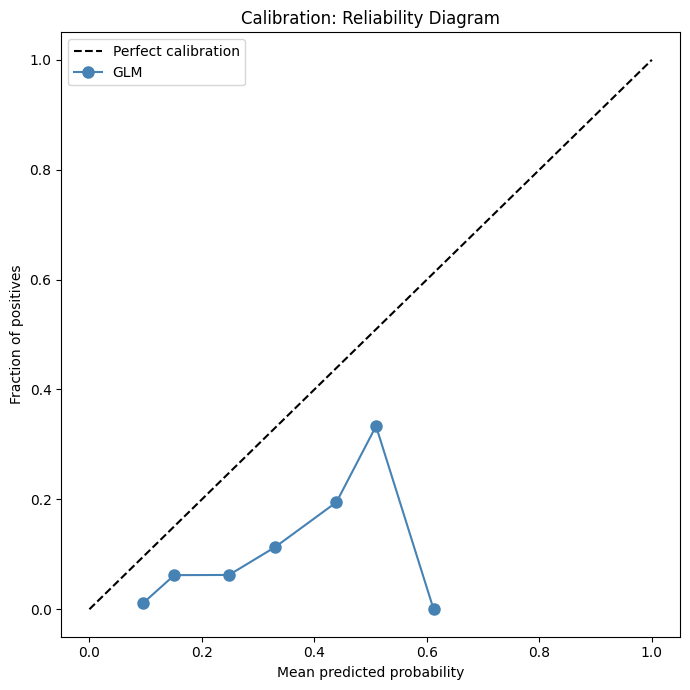

In [7]:
if avail_feats and 'preds_test' in dir():
    fig, ax = plt.subplots(figsize=(7, 7))
    
    # Reliability diagram: bin predictions
    bins = np.linspace(0, 1, 11)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    y_true_arr = test_clean['frac_low'].values
    pred_arr = preds_test
    
    bin_true = []
    bin_pred = []
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (pred_arr >= lo) & (pred_arr < hi)
        if mask.sum() > 0:
            bin_true.append(y_true_arr[mask].mean())
            bin_pred.append(pred_arr[mask].mean())
    
    ax.plot([0,1],[0,1],'k--',label='Perfect calibration')
    ax.plot(bin_pred, bin_true, 'o-', color='steelblue', markersize=8, label='GLM')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title('Calibration: Reliability Diagram')
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR + 'nb08_calibration.png', dpi=80, bbox_inches='tight')
    plt.show()

In [8]:
print("=" * 60)
print("CV DESIGN RECOMMENDATION")
print("=" * 60)
print()
print("Recommended CV scheme: 60-day temporal blocking")
print("Rationale: balances variance and bias in fold estimates")
print("Train/test split: 80/20 chronological")
print()
print("Metrics to optimize: Brier score (primary), log-loss (secondary)")
print("AUC-ROC: supplementary for threshold-independent comparison")

# Save train/test indices for NB09 reuse
if avail_feats:
    tgt_clean_all = tgt[['date','n_total','n_low','frac_low'] + avail_feats].dropna()
    n_all = len(tgt_clean_all)
    split_i = int(n_all * 0.8)
    split_date = tgt_clean_all.iloc[split_i]['date']
    pd.DataFrame({'split_date': [str(split_date.date())]}).to_csv(DATA_DIR + 'nb08_split_date.csv', index=False)
    print(f"\nTrain/test split date: {split_date.date()}")
    print("Saved nb08_split_date.csv")

CV DESIGN RECOMMENDATION

Recommended CV scheme: 60-day temporal blocking
Rationale: balances variance and bias in fold estimates
Train/test split: 80/20 chronological

Metrics to optimize: Brier score (primary), log-loss (secondary)
AUC-ROC: supplementary for threshold-independent comparison

Train/test split date: 2025-06-06
Saved nb08_split_date.csv


## Iteration 2: IPW-Weighted CV, Season-Stratified CV, Calendar Feature Comparison

In [9]:
# ── Iteration 2 setup ──────────────────────────────────────────────────────
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import brier_score_loss, roc_auc_score
import warnings; warnings.filterwarnings('ignore')

DATA_DIR = '/Users/dlau/repos/fish-welfare/data/'
tgt = pd.read_csv(DATA_DIR + 'nb04_target_features.csv', parse_dates=['date']).sort_values('date')
split_date = pd.read_csv(DATA_DIR + 'nb08_split_date.csv')['split_date'].iloc[0]

features_base = ['night_precip_sum','precip_2d_sum','night_wind_min']
features_cal  = ['month_sin','doy_cos','night_precip_sum','precip_2d_sum','night_wind_min']

tgt2 = tgt[features_cal + ['frac_low','n_total','n_low','date']].dropna()
tgt2['bad_day'] = (tgt2['frac_low'] >= 0.3).astype(int)
tgt2['season'] = pd.to_datetime(tgt2['date']).dt.month.map(
    lambda m: 'winter' if m in [12,1,2] else ('monsoon' if m in [6,7,8,9] else 'other'))

train = tgt2[tgt2.date < split_date]; test = tgt2[tgt2.date >= split_date]

if len(train) > 5 and len(test) > 5:
    scaler = StandardScaler().fit(train[features_cal])

    results = {}
    for fname, feats in [('Without calendar', features_base), ('With calendar', features_cal)]:
        sc2 = StandardScaler().fit(train[feats])
        X_tr = sc2.transform(train[feats]); X_te = sc2.transform(test[feats])
        lr = LogisticRegression(max_iter=500, C=1.0)
        lr.fit(X_tr, train['bad_day'])
        p = lr.predict_proba(X_te)[:,1]
        if test['bad_day'].std() > 0:
            brier = brier_score_loss(test['bad_day'], p)
            auc = roc_auc_score(test['bad_day'], p)
        else:
            brier = np.nan; auc = np.nan
        results[fname] = {'Brier': brier, 'AUC': auc}
        print(f"{fname}: Brier={brier:.4f}, AUC={auc:.3f}")


Without calendar: Brier=0.1104, AUC=0.660
With calendar: Brier=0.1369, AUC=0.699


In [10]:
# ── Season-stratified CV ─────────────────────────────────────────────────────
from sklearn.model_selection import LeaveOneGroupOut

print("\nSeason-stratified leave-one-season-out CV:")
X_all = StandardScaler().fit_transform(tgt2[features_cal])
y_all = tgt2['bad_day'].values
groups = tgt2['season'].values

logo = LeaveOneGroupOut()
brier_scores = []
for train_idx, test_idx in logo.split(X_all, y_all, groups):
    if len(np.unique(y_all[train_idx])) < 2: continue
    lr = LogisticRegression(max_iter=500, C=1.0)
    lr.fit(X_all[train_idx], y_all[train_idx])
    p = lr.predict_proba(X_all[test_idx])[:,1]
    season_name = groups[test_idx[0]]
    if y_all[test_idx].std() > 0:
        b = brier_score_loss(y_all[test_idx], p)
        brier_scores.append((season_name, b, len(test_idx)))
        print(f"  Left-out={season_name:<12}: Brier={b:.4f}, n={len(test_idx)}")
    else:
        print(f"  Left-out={season_name:<12}: skipped (no variance)")

if brier_scores:
    avg_b = np.mean([x[1] for x in brier_scores])
    print(f"  Mean LOSO Brier: {avg_b:.4f}")



Season-stratified leave-one-season-out CV:
  Left-out=monsoon     : Brier=0.2291, n=232
  Left-out=other       : Brier=0.1379, n=315
  Left-out=winter      : Brier=0.1362, n=199
  Mean LOSO Brier: 0.1677
